1) Install packages

In [ ]:
!pip -q install torch numpy pandas matplotlib

2) Imports and seed

In [ ]:
import random, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch import optim

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

3) Synthetic dataset


In [ ]:
class SyntheticMotionDataset(Dataset):
    def __init__(self, n_samples=200, seq_len=10, size=28, min_radius=2, max_radius=3):
        self.n_samples = n_samples
        self.seq_len = seq_len
        self.size = size
        self.min_radius = min_radius
        self.max_radius = max_radius

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        H = W = self.size
        r = np.random.randint(self.min_radius, self.max_radius + 1)
        x = np.random.randint(r, W - r)
        y = np.random.randint(r, H - r)
        vx = np.random.choice([-2, -1, 1, 2])
        vy = np.random.choice([-2, -1, 1, 2])
        ax = np.random.choice([-1, 0, 1])
        ay = np.random.choice([-1, 0, 1])

        frames = np.zeros((self.seq_len, 1, H, W), dtype=np.float32)
        yy, xx = np.ogrid[:H, :W]

        for t in range(self.seq_len):
            img = np.zeros((H, W), dtype=np.float32)
            mask = (xx - int(x))**2 + (yy - int(y))**2 <= r*r
            img[mask] = 1.0
            frames[t, 0] = img

            vx = int(np.clip(vx + ax, -3, 3))
            vy = int(np.clip(vy + ay, -3, 3))
            if vx == 0:
                vx = 1
            if vy == 0:
                vy = -1

            x += vx
            y += vy

            if x - r < 0:
                x = r
                vx = abs(vx)
            if x + r >= W:
                x = W - r - 1
                vx = -abs(vx)
            if y - r < 0:
                y = r
                vy = abs(vy)
            if y + r >= H:
                y = H - r - 1
                vy = -abs(vy)

        return torch.from_numpy(frames)

4) Model

In [ ]:
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, k=3):
        super().__init__()
        p = k // 2
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, k, padding=p)

    def forward(self, x, h, c):
        y = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.chunk(y, 4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c

class ConvLSTMVideoPredictor(nn.Module):
    def __init__(self, in_ch=1, hid_ch=8):
        super().__init__()
        self.hid_ch = hid_ch
        self.cell = ConvLSTMCell(in_ch, hid_ch)
        self.out_conv = nn.Conv2d(hid_ch, in_ch, 1)

    def init_state(self, b, h, w, device):
        h_state = torch.zeros(b, self.hid_ch, h, w, device=device)
        c_state = torch.zeros(b, self.hid_ch, h, w, device=device)
        return h_state, c_state

    def forward(self, x, pred_len=5):
        b, t, c, h, w = x.shape
        h_state, c_state = self.init_state(b, h, w, x.device)

        for i in range(t):
            h_state, c_state = self.cell(x[:, i], h_state, c_state)

        inp = x[:, -1]
        outs = []
        for _ in range(pred_len):
            h_state, c_state = self.cell(inp, h_state, c_state)
            frame = torch.sigmoid(self.out_conv(h_state))
            outs.append(frame.unsqueeze(1))
            inp = frame

        return torch.cat(outs, dim=1)

5) Losses and metrics


In [ ]:
def reconstruction_loss(pred, target):
    return nn.functional.mse_loss(pred, target)

def pcal_loss(pred):
    if pred.size(1) < 3:
        return torch.tensor(0.0, device=pred.device)
    velocity_1 = pred[:, 1:-1] - pred[:, :-2]
    velocity_2 = pred[:, 2:] - pred[:, 1:-1]
    acceleration = velocity_2 - velocity_1
    return torch.mean(acceleration.pow(2))

def temporal_consistency_score(pred, target):
    return float(1.0 - nn.functional.l1_loss(pred[:, 1:] - pred[:, :-1], target[:, 1:] - target[:, :-1]).item())

def motion_smoothness_index(pred):
    if pred.size(1) < 3:
        return 0.0
    acc = (pred[:, 2:] - pred[:, 1:-1]) - (pred[:, 1:-1] - pred[:, :-2])
    return float(acc.abs().mean().item())

6) Train and eval

In [ ]:
def train_epoch(model, loader, opt, device, lam=0.0, input_len=5):
    model.train()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        x = batch[:, :input_len]
        y = batch[:, input_len:]
        pred = model(x, pred_len=y.size(1))
        loss = reconstruction_loss(pred, y) + lam * pcal_loss(pred)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item() * batch.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device, lam=0.0, input_len=5):
    model.eval()
    total = tcs = msi = 0.0
    for batch in loader:
        batch = batch.to(device)
        x = batch[:, :input_len]
        y = batch[:, input_len:]
        pred = model(x, pred_len=y.size(1))
        loss = reconstruction_loss(pred, y) + lam * pcal_loss(pred)
        total += loss.item() * batch.size(0)
        tcs += temporal_consistency_score(pred, y) * batch.size(0)
        msi += motion_smoothness_index(pred) * batch.size(0)
    n = len(loader.dataset)
    return total / n, tcs / n, msi / n

7) Visualization


In [ ]:
def show_sequence(x, y, p, n=5):
    x = x[0].cpu().numpy()
    y = y[0].cpu().numpy()
    p = p[0].cpu().numpy()
    fig, axes = plt.subplots(3, n, figsize=(2*n, 5))
    for i in range(n):
        axes[0, i].imshow(x[i, 0], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(y[i, 0], cmap='gray')
        axes[1, i].axis('off')
        axes[2, i].imshow(p[i, 0], cmap='gray')
        axes[2, i].axis('off')
    plt.tight_layout()
    plt.show()

8) DataLoader


In [ ]:
ds = SyntheticMotionDataset(n_samples=200, seq_len=10, size=28)
train_size = int(0.8 * len(ds))
val_size = len(ds) - train_size
train_ds, val_ds = random_split(ds, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)

9) Train baseline


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

baseline = ConvLSTMVideoPredictor().to(device)
opt = optim.Adam(baseline.parameters(), lr=1e-3)

base_hist = []
for epoch in range(1):
    tr = train_epoch(baseline, train_loader, opt, device, lam=0.0, input_len=5)
    va, tcs, msi = evaluate(baseline, val_loader, device, lam=0.0, input_len=5)
    base_hist.append([epoch+1, tr, va, tcs, msi])
    print('Baseline', epoch+1, tr, va, tcs, msi)

Baseline 1 0.20438953191041948 0.197572523355484 0.9731455747038126 0.00046820296556688846


10) Train proposed model


In [ ]:
proposed = ConvLSTMVideoPredictor().to(device)
opt2 = optim.Adam(proposed.parameters(), lr=1e-3)

prop_hist = []
for epoch in range(1):
    tr = train_epoch(proposed, train_loader, opt2, device, lam=0.1, input_len=5)
    va, tcs, msi = evaluate(proposed, val_loader, device, lam=0.1, input_len=5)
    prop_hist.append([epoch+1, tr, va, tcs, msi])
    print('Proposed', epoch+1, tr, va, tcs, msi)

Proposed 1 0.16928269863128662 0.16313947439193727 0.9688467442989349 0.0005653493572026491


11) Compare results


In [ ]:
base_df = pd.DataFrame(base_hist, columns=['epoch','train_loss','val_loss','temporal_consistency','motion_smoothness'])
prop_df = pd.DataFrame(prop_hist, columns=['epoch','train_loss','val_loss','temporal_consistency','motion_smoothness'])

print(base_df.to_string(index=False))
print(prop_df.to_string(index=False))

 epoch  train_loss  val_loss  temporal_consistency  motion_smoothness
     1     0.20439  0.197573              0.973146           0.000468
 epoch  train_loss  val_loss  temporal_consistency  motion_smoothness
     1    0.169283  0.163139              0.968847           0.000565


12) Show predictions


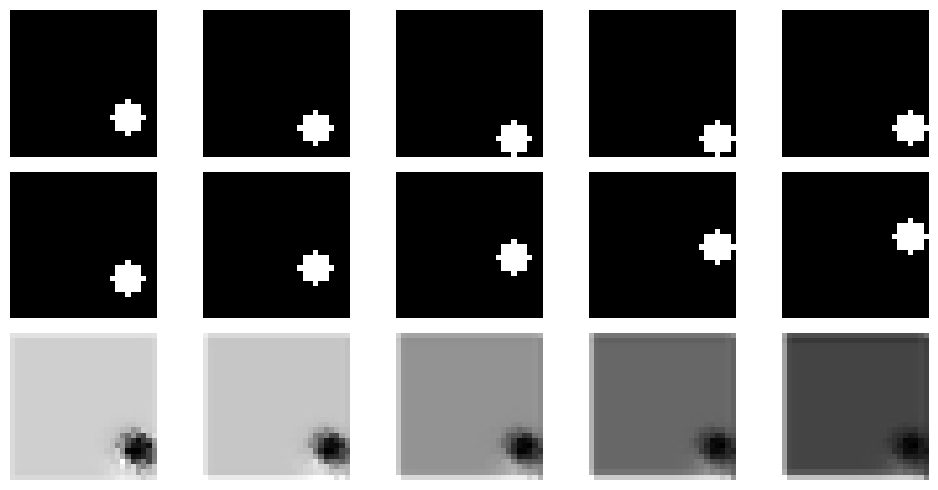

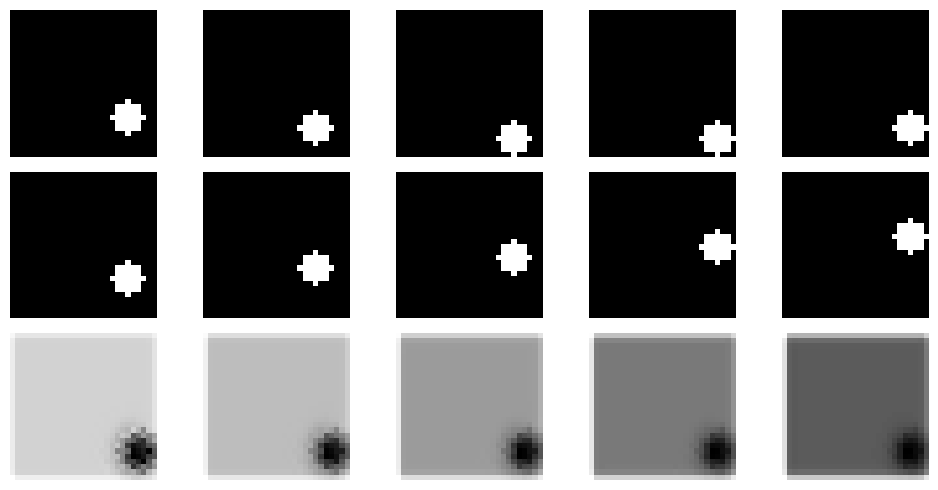

In [ ]:
batch = next(iter(val_loader)).to(device)
x = batch[:, :5]
y = batch[:, 5:]

with torch.no_grad():
    p1 = baseline(x, pred_len=5)
    p2 = proposed(x, pred_len=5)

show_sequence(x, y, p1)
show_sequence(x, y, p2)

13) Save results


In [ ]:
base_df.to_csv('baseline_results.csv', index=False)
prop_df.to_csv('proposed_results.csv', index=False)
torch.save(baseline.state_dict(), 'baseline_model.pt')
torch.save(proposed.state_dict(), 'proposed_model.pt')

print('Saved outputs')

Saved outputs
